# Разведочный анализ данных. Исследование и визуализация данных.

## Цель лабораторной работы:
Изучение различных методов визуализации данных.

## Краткое описание:
Построение основных графиков, входящих в этап разведочного анализа данных.

## Задание:
1. Выбрать набор данных (датасет).
2. Создать ноутбук, который содержит следующие разделы:
   - Текстовое описание выбранного Вами набора данных.
   - Основные характеристики датасета.
   - Визуальное исследование датасета.
   - Информация о корреляции признаков.
3. Сформировать отчет и разместить его в своем репозитории на github.

---

## Установка необходимых библиотек

In [25]:
!pip install pandas scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


## Импорт необходимых библиотек

In [26]:
import pandas as pd
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import seaborn as sns

## Выбор и загрузка датасета

Для данной лабораторной работы выбран датасет `wine` из библиотеки `scikit-learn`. Этот датасет содержит информацию о химическом составе вин, выращенных в одном и том же регионе Италии, но принадлежащих трем разным сортам (классам).

In [27]:
# Загрузка датасета wine
wine = load_wine()

# Преобразование в Pandas DataFrame
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

print("Первые 5 строк датасета:")
print(df.head())

Первые 5 строк датасета:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  prol

## Текстовое описание выбранного Вами набора данных

Датасет `wine` содержит 13 атрибутов (признаков), описывающих различные химические свойства вина, такие как алкоголь, яблочная кислота, зола, щелочность золы, магний, общее количество фенолов, флавоноиды, нефлавоноидные фенолы, проантоцианидины, интенсивность цвета, оттенок, OD280/OD315 разбавленных вин и пролин. Целевая переменная `target` представляет собой сорт вина (0, 1 или 2).

Этот датасет является классическим примером для задач классификации и не содержит пропусков, что упрощает разведочный анализ данных.

## Основные характеристики датасета

In [28]:
print("Размерность датасета (строки, столбцы):")
print(df.shape)

print("\nИнформация о типах данных и пропущенных значениях:")
print(df.info())

print("\nОсновные статистические характеристики датасета:")
print(df.describe())

Размерность датасета (строки, столбцы):
(178, 14)

Информация о типах данных и пропущенных значениях:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_dilute

Из вывода `df.info()` видно, что датасет не содержит пропущенных значений, а все признаки имеют числовой тип данных (float64 или int64). `df.describe()` предоставляет сводную статистику по каждому числовому признаку: количество, среднее, стандартное отклонение, минимальное и максимальное значения, а также квартили.

## Визуальное исследование датасета

### Распределение целевой переменной

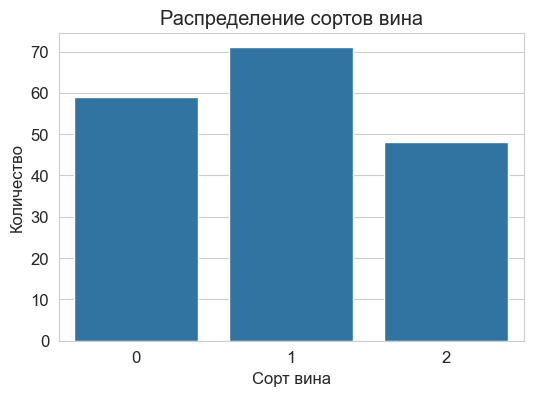

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Распределение сортов вина')
plt.xlabel('Сорт вина')
plt.ylabel('Количество')
plt.show()

График `countplot` показывает, что классы в целевой переменной распределены относительно равномерно, хотя класс 1 немного преобладает.

### Гистограммы для числовых признаков

Позволяют оценить распределение каждого признака.

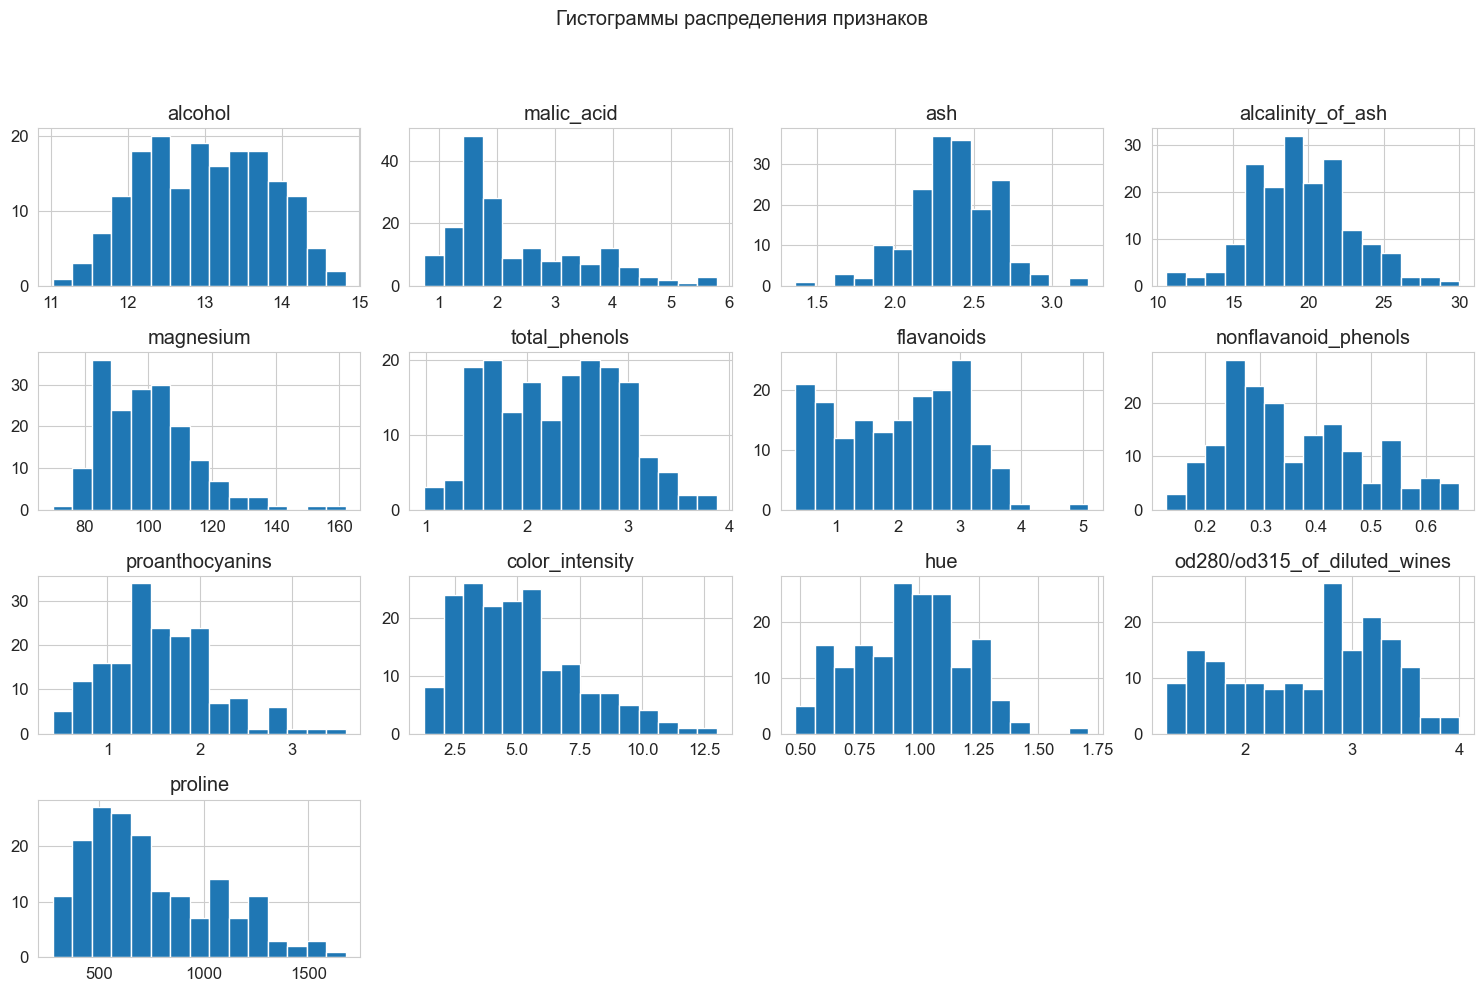

In [30]:
df.drop('target', axis=1).hist(bins=15, figsize=(15, 10), layout=(4, 4))
plt.suptitle('Гистограммы распределения признаков', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Гистограммы показывают форму распределения каждого признака. Некоторые признаки, такие как `magnesium` или `proline`, имеют скошенное распределение, что может указывать на наличие выбросов или необходимость преобразования для некоторых моделей машинного обучения.

### Ящичковые диаграммы (Box plots) для числовых признаков

Позволяют выявить выбросы и оценить разброс данных.

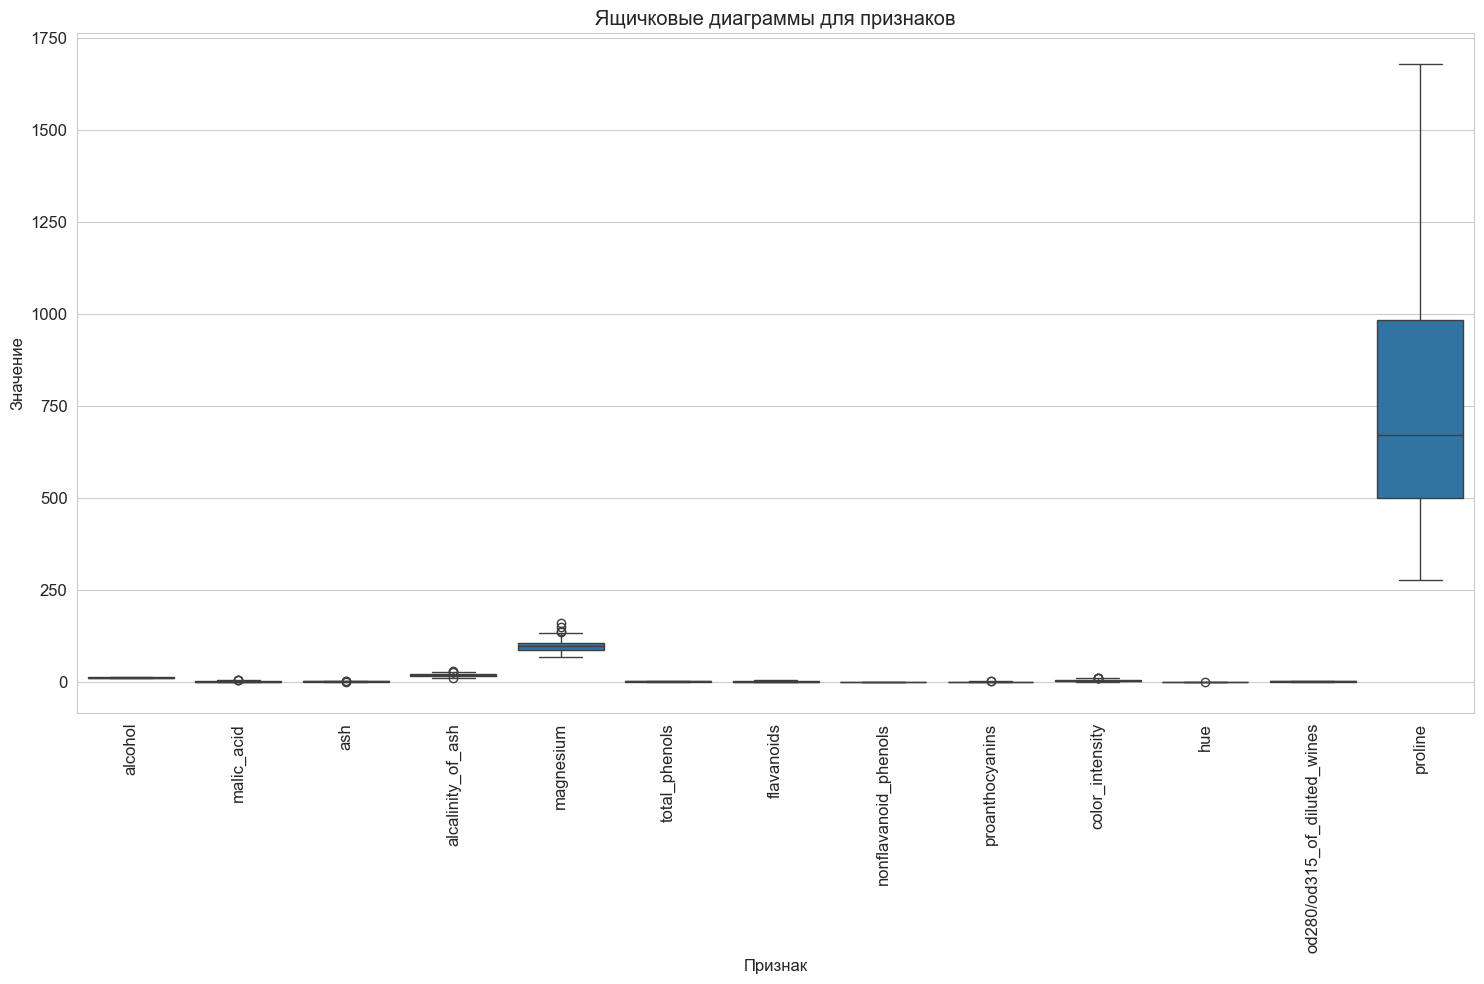

In [31]:
plt.figure(figsize=(15, 10))
df_melted = df.drop('target', axis=1).melt()
sns.boxplot(x='variable', y='value', data=df_melted)
plt.xticks(rotation=90)
plt.title('Ящичковые диаграммы для признаков')
plt.xlabel('Признак')
plt.ylabel('Значение')
plt.tight_layout()
plt.show()

Ящичковые диаграммы подтверждают наличие выбросов в некоторых признаках, например, `magnesium`, `proline`, `ash`, `alcalinity_of_ash` и `malic_acid`. Это важно учитывать при дальнейшем анализе и моделировании.

### Парные графики (Pair plots)

Позволяют визуализировать взаимосвязь между каждой парой признаков, а также распределение каждого признака. `hue='target'` позволяет раскрасить точки в зависимости от сорта вина, что помогает увидеть, насколько признаки разделяют классы.

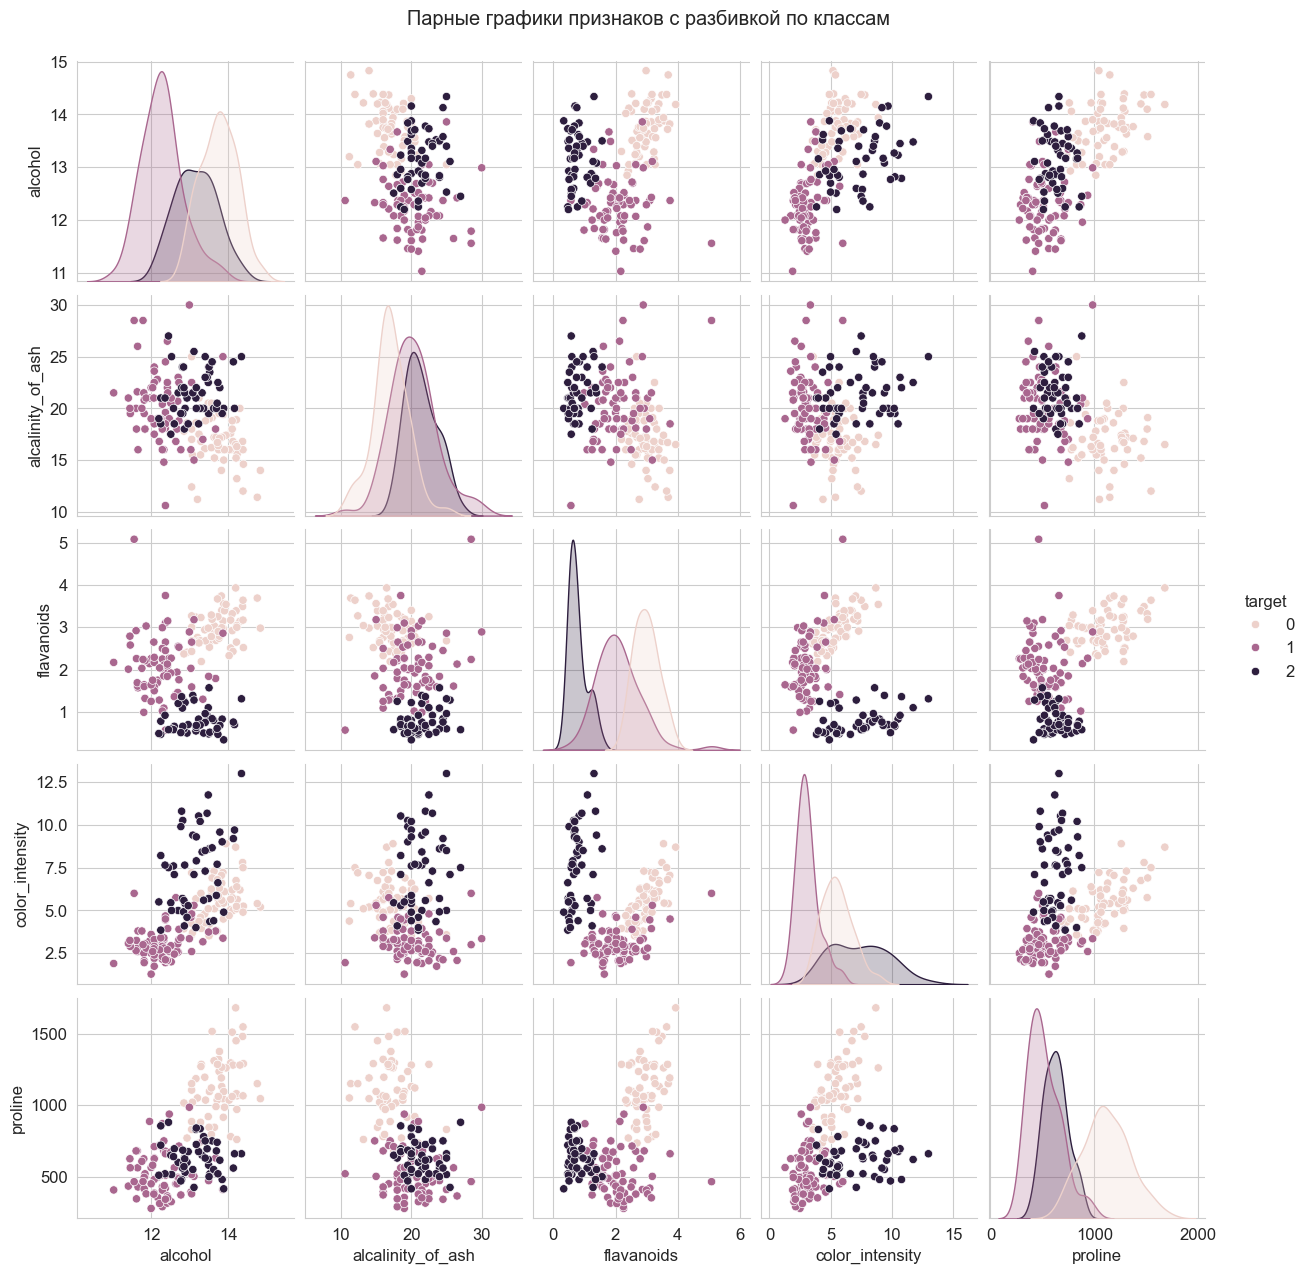

In [32]:
sns.pairplot(df, hue='target', vars=df.columns[:-1][::3]) # Выбираем часть признаков для лучшей читаемости
plt.suptitle('Парные графики признаков с разбивкой по классам', y=1.02)
plt.show()

Парные графики полезны для быстрого обнаружения линейных или нелинейных зависимостей между признаками, а также для оценки того, насколько хорошо признаки разделяют классы. Например, видно, что `proline` и `color_intensity` хорошо разделяют классы.

## Информация о корреляции признаков

Корреляционная матрица показывает степень линейной взаимосвязи между парами признаков. Тепловая карта (heatmap) является удобным способом визуализации корреляционной матрицы.

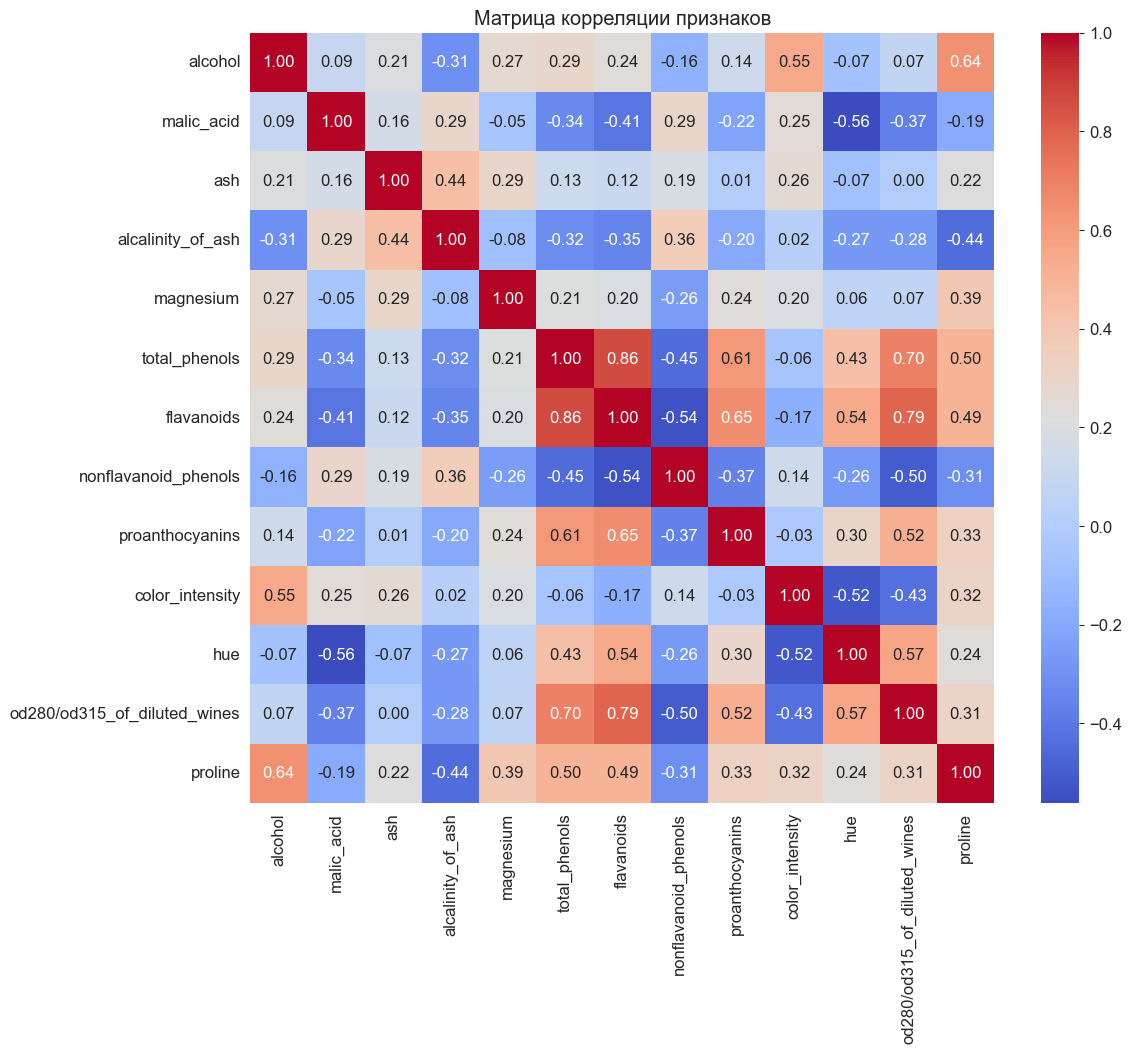

In [33]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.drop('target', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

Тепловая карта корреляции позволяет выявить сильно коррелирующие признаки (положительно или отрицательно). Например, видно сильную положительную корреляцию между `flavanoids` и `total_phenols`, а также отрицательную корреляцию между `alcohol` и `malic_acid`. Сильно коррелирующие признаки могут привести к мультиколлинеарности в некоторых моделях машинного обучения, что может повлиять на их интерпретируемость или стабильность.